# 3D velocity visualization

dynamo can visualize RNA-velocity vector fields in **three dimensions**. This tutorial shows how to:

1. compute a 3-component UMAP embedding and project velocities onto it, and
2. render the per-cell velocity vectors in 3D with `dyn.pl.cell_wise_vectors_3d`.

The static `matplotlib` renderer is used here; an interactive `pyvista` renderer is also available (`plot_method="pv"`).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')

## 1. Preprocess and estimate velocity

We use the zebrafish sample dataset and the standard dynamo workflow: preprocess, then estimate RNA velocity with `dyn.tl.dynamics`.

In [2]:
adata = dyn.sample_data.zebrafish()
celltype_key = 'Cell_type'

preprocessor = dyn.pp.Preprocessor()
preprocessor.preprocess_adata(adata, recipe='monocle')
dyn.tl.dynamics(adata, model='stochastic', cores=4)
adata

|-----> File ./data/zebrafish.h5ad already exists.


|-----> Running monocle preprocessing pipeline...


|-----------> filtered out 14 outlier cells


|-----------> filtered out 12746 outlier genes


|-----> PCA dimension reduction


...

|-----------> making adata smooth...


|-----> calculating first/second moments...


|-----> [moments calculation] completed [32.9216s]



╭─ SUMMARY: dynamics ────────────────────────────────────────────────╮
│  Duration: 40.4413s                                                │
│  Shape:    4,167 x 16,940 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_dynamics (bool)                              │
│                                                                    │
│  ● UNS    │ ✚ dynamics                                             │
│           │ ✚ vel_params_names                                     │
│                                                                    │
│  ● OBSP   │ ✚ moments_con (sparse matrix, 4167x4167)               │
│                                                                    │
│  ● LAYERS │ ✚ M_s (sparse matrix, 4167x16940)                      │
│    

AnnData object with n_obs × n_vars = 4167 × 16940
    obs: 'split_id', 'sample', 'Size_Factor', 'condition', 'Cluster', 'Cell_type', 'umap_1', 'umap_2', 'batch', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'initial_cell_size', 'ntr'
    var: 'nCells', 'nCounts', 'pass_basic_filter', 'log_cv', 'log_m', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics'
    uns: 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'history_log', 'vel_params_names', 'dynamics'
    obsm: 'X_pca'
    varm: 'vel_params'
    layers: 'spliced', 'unspliced', 'X_spliced', 'X_unspliced', 'M_u', 'M_uu', 'M_s', 'M_us', 'M_ss', 'velocity_S'
    obsp: 'moments_con'

## 2. A 3-component UMAP and projected velocities

`cell_wise_vectors_3d` needs a 3-dimensional embedding (`x`, `y`, `z`) and the velocity projected onto it. We compute a 3-component UMAP (`n_components=3`, `enforce=True` to recompute over any cached 2D embedding) and then project the velocities onto that basis with `dyn.tl.cell_velocities`.

In [3]:
dyn.tl.reduceDimension(adata, basis='umap', n_components=3, enforce=True)
dyn.tl.cell_velocities(adata, basis='umap')

print('X_umap:', adata.obsm['X_umap'].shape, '| velocity_umap:', adata.obsm['velocity_umap'].shape)

|-----> retrieve data for non-linear dimension reduction...


|-----> [UMAP] using X_umap with n_pca_components = 30


|-----> <insert> X_umap to obsm in AnnData Object.


|-----> [UMAP] completed [12.3662s]



╭─ SUMMARY: reduceDimension ─────────────────────────────────────────╮
│  Duration: 12.3675s                                                │
│  Shape:    4,167 x 16,940 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 30, 'method': 'umap'}       │
│           │ ✚ umap_fit                                             │
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 4167x3)                               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
|-----> incomplete neighbor graph info detected: connectivities and distance

...

|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%

|-----> [projecting velocity vector to low dimensional embedding] completed [0.4320s]


|-----> method arg is None, choosing methods automatically...


|-----------> method kd_tree selected



╭─ SUMMARY: cell_velocities ─────────────────────────────────────────╮
│  Duration: 4.6045s                                                 │
│  Shape:    4,167 x 16,940 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_transition (bool)                            │
│                                                                    │
│  ● UNS    │ ✚ grid_velocity_umap                                   │
│                                                                    │
│  ● OBSP   │ ✚ connectivities (sparse matrix, 4167x4167)            │
│           │ ✚ distances (sparse matrix, 4167x4167)                 │
│           │ ✚ pearson_transition_matrix (sparse matrix, 4167x4167) │
│                                                                    │
│  ● 

## 3. 3D cell-wise velocity vectors

`dyn.pl.cell_wise_vectors_3d` draws one velocity arrow per cell in the 3D embedding, colored by an annotation.

|-----> X shape: (4167, 3) V shape: (4167, 3)


|-----------> plotting with basis key=X_umap


|-----------> skip filtering Cell_type by stack threshold when stacking color because it is not a numeric type


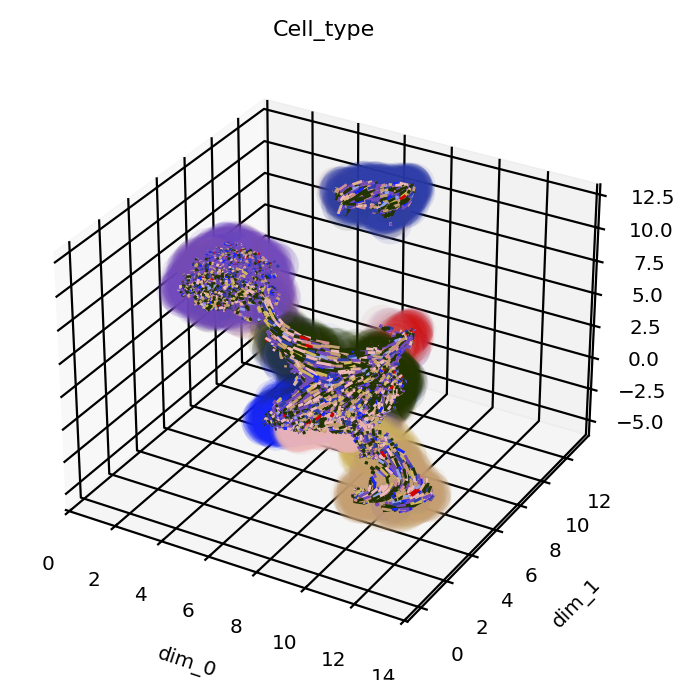

In [4]:
dyn.pl.cell_wise_vectors_3d(
    adata,
    basis='umap',
    color=[celltype_key],
    plot_method='matplotlib',
    elev=30,
    azim=-60,
)

You can change the viewing angle with `elev` / `azim`:

|-----> X shape: (4167, 3) V shape: (4167, 3)


|-----------> plotting with basis key=X_umap


|-----------> skip filtering Cell_type by stack threshold when stacking color because it is not a numeric type


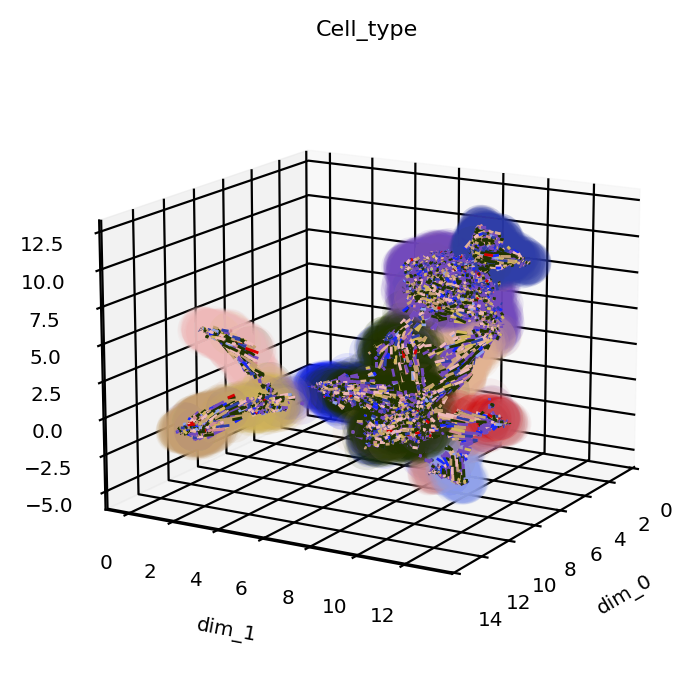

In [5]:
dyn.pl.cell_wise_vectors_3d(
    adata,
    basis='umap',
    color=[celltype_key],
    plot_method='matplotlib',
    elev=15,
    azim=30,
)

## 4. Interactive 3D and the wider 3D toolkit

For an interactive, rotatable view, pass `plot_method="pv"` to render with [PyVista](https://pyvista.org/) (or use the Plotly backend), which requires `pyvista` and a display / off-screen backend:

```python
dyn.pl.cell_wise_vectors_3d(adata, basis='umap', color=[celltype_key], plot_method='pv')
```

As of dynamo v1.4, the 3D visualization toolkit (Plotly + PyVista) also includes:

- `dyn.pl.scatters_interactive()` — interactive 3D scatter plots
- `dyn.pl.cell_wise_vectors_3d()` — 3D per-cell velocity vectors (this tutorial)
- `dyn.pl.topography_3d()` — 3D vector-field topography
- `dyn.mv.PyvistaAnim()` — 3D animations with PyVista

## Summary

- Compute a 3-component embedding (`reduceDimension(..., n_components=3)`) and project velocities onto it (`cell_velocities`).
- `dyn.pl.cell_wise_vectors_3d` renders the 3D velocity field, statically with `matplotlib` or interactively with `pyvista` / `plotly`.
